# ch199 — Matrix Exponentials and Dynamical Systems

> **Prerequisites:** ch169 (Eigenvectors), ch172 (Diagonalization), ch173 (SVD), ch176 (Matrix Calculus Introduction)
> **You will learn:**
> - What the matrix exponential $e^{At}$ computes
> - How diagonalization gives closed-form ODE solutions
> - Stability analysis via eigenvalue real parts
> - Discrete vs. continuous linear dynamical systems
> - Applications in physics, control theory, and recurrent networks
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

The **linear ODE** $\dot{\mathbf{x}} = A\mathbf{x}$ with initial condition $\mathbf{x}(0) = \mathbf{x}_0$ has the solution $\mathbf{x}(t) = e^{At}\mathbf{x}_0$ where $e^{At}$ is the **matrix exponential** — defined by the same Taylor series as the scalar exponential:
$$e^{At} = I + At + \frac{(At)^2}{2!} + \ldots$$

The matrix exponential cannot be computed entry-by-entry. But via eigendecomposition *(ch172)*: if $A = V\Lambda V^{-1}$, then $e^{At} = Ve^{\Lambda t}V^{-1}$ where $e^{\Lambda t}$ is diagonal with entries $e^{\lambda_i t}$.

**Stability:** $\dot{\mathbf{x}} = A\mathbf{x}$ is stable iff all eigenvalues of $A$ have negative real part. For the discrete system $\mathbf{x}_{t+1} = A\mathbf{x}_t$: stable iff all $|\lambda_i| < 1$.

## 2. Intuition & Mental Models

**Geometric:** the matrix exponential flows points along the vector field $\mathbf{x} \mapsto A\mathbf{x}$. Each eigenvector $\mathbf{v}_i$ of $A$ flows independently: the component along $\mathbf{v}_i$ scales as $e^{\lambda_i t}$. Negative real part → decay; positive → growth; purely imaginary → oscillation.

**Physical:** a coupled spring-damper system $\ddot{x} + 2\zeta\dot{x} + x = 0$ written as $\dot{\mathbf{x}} = A\mathbf{x}$ where $\mathbf{x} = [x, \dot{x}]^\top$. The eigenvalues of $A$ determine whether the system oscillates and decays (underdamped), decays monotonically (overdamped), or grows (unstable).

**RNN connection *(ch177)*:** the discrete recurrence $\mathbf{h}_{t+1} = W\mathbf{h}_t + \mathbf{u}_t$ is exactly $\mathbf{x}_{t+1} = A\mathbf{x}_t$ for the hidden state. Vanishing/exploding gradients correspond to $|\lambda_i| \ll 1$ or $|\lambda_i| \gg 1$.

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_18340\2621961144.py:48: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_18340\2621961144.py:48: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


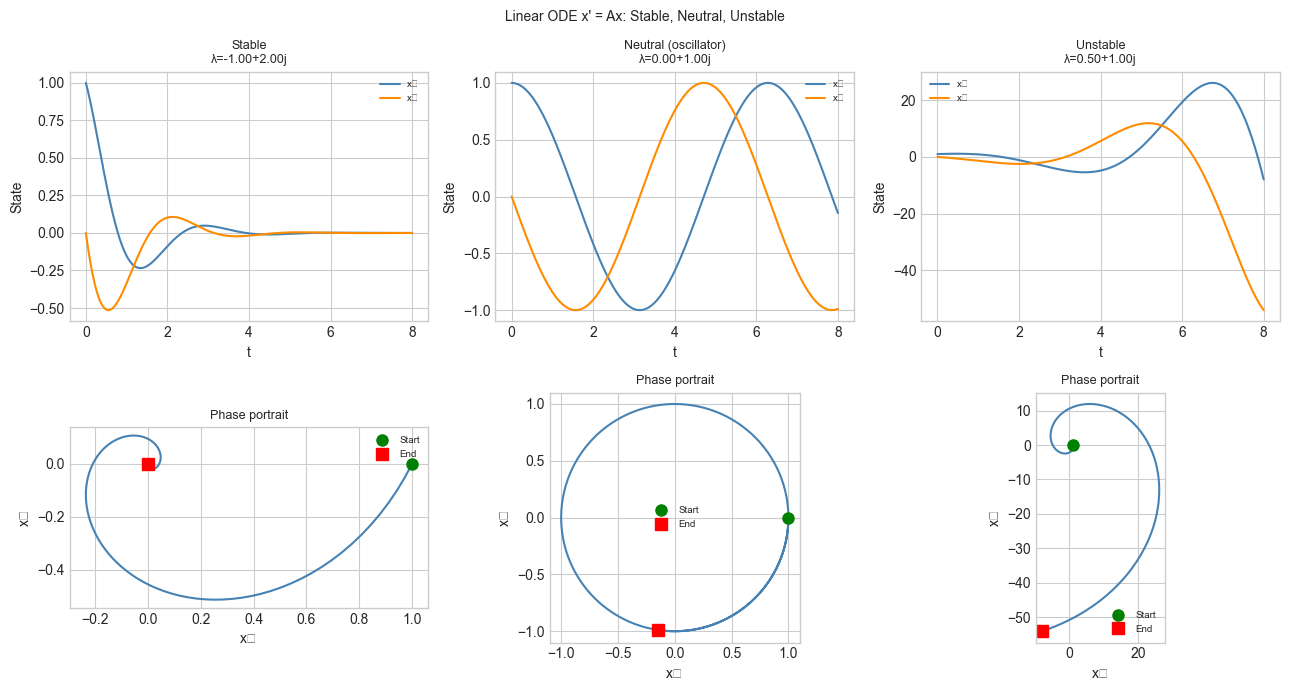

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

def matrix_exp(A, t):
    """Compute e^(At) via eigendecomposition. Valid for diagonalizable A."""
    eigvals, V = np.linalg.eig(A)
    exp_lambda = np.exp(eigvals * t)
    return (V * exp_lambda[None, :]) @ np.linalg.inv(V)

def simulate_ode(A, x0, t_end=8.0, n_steps=300):
    t_vals = np.linspace(0, t_end, n_steps)
    traj = np.array([matrix_exp(A, t).real @ x0 for t in t_vals])
    return t_vals, traj

# Three 2x2 systems: stable, neutral, unstable
A_stable   = np.array([[-1., 2.],[-2.,-1.]])
A_neutral  = np.array([[ 0., 1.],[-1., 0.]])
A_unstable = np.array([[ 0.5, 1.],[-1., 0.5]])

x0 = np.array([1., 0.])
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for col, (A, title) in enumerate([
    (A_stable,   'Stable'),
    (A_neutral,  'Neutral (oscillator)'),
    (A_unstable, 'Unstable'),
]):
    eigs = np.linalg.eigvals(A)
    t_vals, traj = simulate_ode(A, x0)

    axes[0, col].plot(t_vals, traj[:,0], color='steelblue', label='x₁')
    axes[0, col].plot(t_vals, traj[:,1], color='darkorange', label='x₂')
    axes[0, col].set_title(f'{title}\nλ={eigs[0]:.2f}', fontsize=9)
    axes[0, col].set_xlabel('t'); axes[0, col].set_ylabel('State')
    axes[0, col].legend(fontsize=7)

    axes[1, col].plot(traj[:,0], traj[:,1], color='steelblue')
    axes[1, col].plot(*x0, 'go', ms=8, label='Start')
    axes[1, col].plot(*traj[-1], 'rs', ms=8, label='End')
    axes[1, col].set_xlabel('x₁'); axes[1, col].set_ylabel('x₂')
    axes[1, col].set_title('Phase portrait', fontsize=9)
    axes[1, col].legend(fontsize=7)
    axes[1, col].set_aspect('equal')

plt.suptitle("Linear ODE x' = Ax: Stable, Neutral, Unstable", fontsize=10)
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Matrix exponential:**
$$e^A = \sum_{k=0}^{\infty} \frac{A^k}{k!}$$

**Diagonalizable case** $A = V\Lambda V^{-1}$:
$$e^{At} = V e^{\Lambda t} V^{-1}, \quad e^{\Lambda t} = \text{diag}(e^{\lambda_1 t}, \ldots, e^{\lambda_n t})$$

**Solution decomposition:** expand $\mathbf{x}_0 = \sum_i c_i \mathbf{v}_i$, then:
$$\mathbf{x}(t) = \sum_i c_i e^{\lambda_i t} \mathbf{v}_i$$
Each mode $i$ evolves independently at rate $\lambda_i$.

**Stability criteria:**
- Continuous: $\text{Re}(\lambda_i) < 0$ for all $i$
- Discrete ($\mathbf{x}_{t+1} = A\mathbf{x}_t$): $|\lambda_i| < 1$ for all $i$

**Lyapunov function:** $V(\mathbf{x}) = \mathbf{x}^\top P \mathbf{x}$ for a positive definite $P$ satisfying $A^\top P + PA = -Q$ (Lyapunov equation, a Sylvester equation *(ch198)*) certifies stability.

## 5. Python Implementation

In [2]:
def matrix_exp_scaling_squaring(A, n_terms=15):
    """
    Matrix exponential via scaling-and-squaring + Taylor series.
    More numerically stable than naive Taylor for large ||A||.
    
    Idea: e^A = (e^(A/2^s))^(2^s), choosing s so ||A/2^s|| is small.
    """
    norm_A = np.linalg.norm(A, ord=1)
    s = max(0, int(np.ceil(np.log2(max(norm_A, 1e-10)))))
    A_sc = A / (2**s)

    # Taylor series for e^(A_sc)
    result = np.eye(A.shape[0])
    term   = np.eye(A.shape[0])
    for k in range(1, n_terms):
        term   = term @ A_sc / k
        result = result + term
        if np.linalg.norm(term) < 1e-15 * np.linalg.norm(result):
            break

    # Square back s times
    for _ in range(s):
        result = result @ result
    return result

# Validate against eigendecomposition
A_test = rng.normal(0, 0.5, (4, 4))
A_sym  = (A_test - A_test.T) / 2   # antisymmetric: eigenvalues purely imaginary

t_test = 2.5
eA_eig = matrix_exp(A_sym, t_test)
eA_ss  = matrix_exp_scaling_squaring(A_sym * t_test)
print(f'Scaling-squaring vs eig error: {np.linalg.norm(eA_eig - eA_ss):.2e}')

# Verify: e^A for antisymmetric A should be orthogonal (det=1, A.T A = I)
print(f'||R.T R - I|| (should be ~0): {np.linalg.norm(eA_ss.T @ eA_ss - np.eye(4)):.2e}')
print(f'det(e^A) (should be 1): {np.linalg.det(eA_ss):.6f}')

Scaling-squaring vs eig error: 1.18e-15
||R.T R - I|| (should be ~0): 1.42e-15
det(e^A) (should be 1): 1.000000


## 6. Experiments

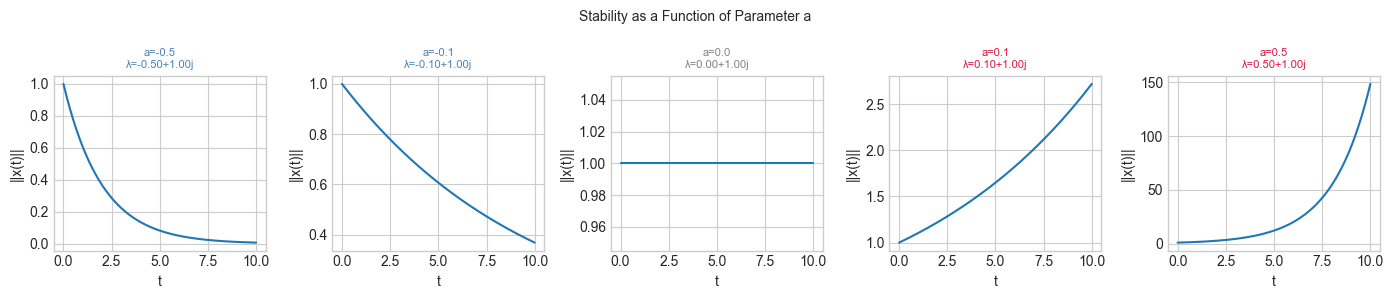

a<0: stable (decays), a=0: marginally stable, a>0: unstable (grows)


In [3]:
# --- Experiment: Stability boundary in parameter space ---
# For the system A = [[a, -1],[1, a]], the stability boundary is Re(λ) = 0 → a = 0.
# Try changing: A_VALS, T_SIM

A_VALS = [-0.5, -0.1, 0.0, 0.1, 0.5]   # <-- stability parameter
T_SIM  = 10.0

fig, axes = plt.subplots(1, len(A_VALS), figsize=(14, 3), sharey=False)
for ax, a_val in zip(axes, A_VALS):
    A_param = np.array([[a_val, -1.],[1., a_val]])
    eigs    = np.linalg.eigvals(A_param)
    t_vals, traj = simulate_ode(A_param, np.array([1., 0.]), T_SIM)
    ax.plot(t_vals, np.linalg.norm(traj, axis=1))
    color = 'steelblue' if a_val < 0 else ('gray' if a_val == 0 else 'crimson')
    ax.set_title(f'a={a_val}\nλ={eigs[0]:.2f}', fontsize=8, color=color)
    ax.set_xlabel('t'); ax.set_ylabel('||x(t)||')

plt.suptitle('Stability as a Function of Parameter a', fontsize=10)
plt.tight_layout()
plt.show()
print('a<0: stable (decays), a=0: marginally stable, a>0: unstable (grows)')

## 7. Exercises

**Easy 1.** For a diagonal matrix $A = \text{diag}(a_1, \ldots, a_n)$, write down $e^{At}$ explicitly. What condition on $a_i$ makes the system stable?

**Easy 2.** Compute $e^A$ for $A = \begin{pmatrix} 0 & \theta \\ -\theta & 0 \end{pmatrix}$ analytically using the Taylor series. What does the result represent geometrically? *(Hint: rotation matrix)*

**Medium 1.** Implement the **Cayley-Hamilton theorem** check: for any $n\times n$ matrix $A$ with characteristic polynomial $p(\lambda) = \det(\lambda I - A)$, the matrix satisfies $p(A) = 0$. Verify for a $3\times3$ example.

**Medium 2.** Simulate the discrete system $\mathbf{x}_{t+1} = W\mathbf{x}_t$ for $W$ with $\rho(W)$ slightly above 1 (unstable) and slightly below 1 (stable). Add a control input: $\mathbf{x}_{t+1} = W\mathbf{x}_t + B\mathbf{u}_t$ and find a feedback gain $K$ such that $\mathbf{u}_t = -K\mathbf{x}_t$ stabilizes the system.

**Hard.** The **Lyapunov equation** $A^\top P + PA = -Q$ (with $Q = I$) determines the steady-state covariance of the stochastic system $\dot{\mathbf{x}} = A\mathbf{x} + \mathbf{w}$. Solve it using the Sylvester solver from ch198 and verify that the resulting $P$ is positive definite (proving stability of $A$).

## 8. Mini Project

Eigenvalues (should be purely imaginary for conservative system):
[ 0.+2.j      0.-2.j     -0.+1.j     -0.-1.j     -0.+1.7321j -0.-1.7321j
  0.+1.7321j  0.-1.7321j -0.+1.j     -0.-1.j      0.+0.j     -0.+0.j    ]
Max real part: 5.848455470742119e-09


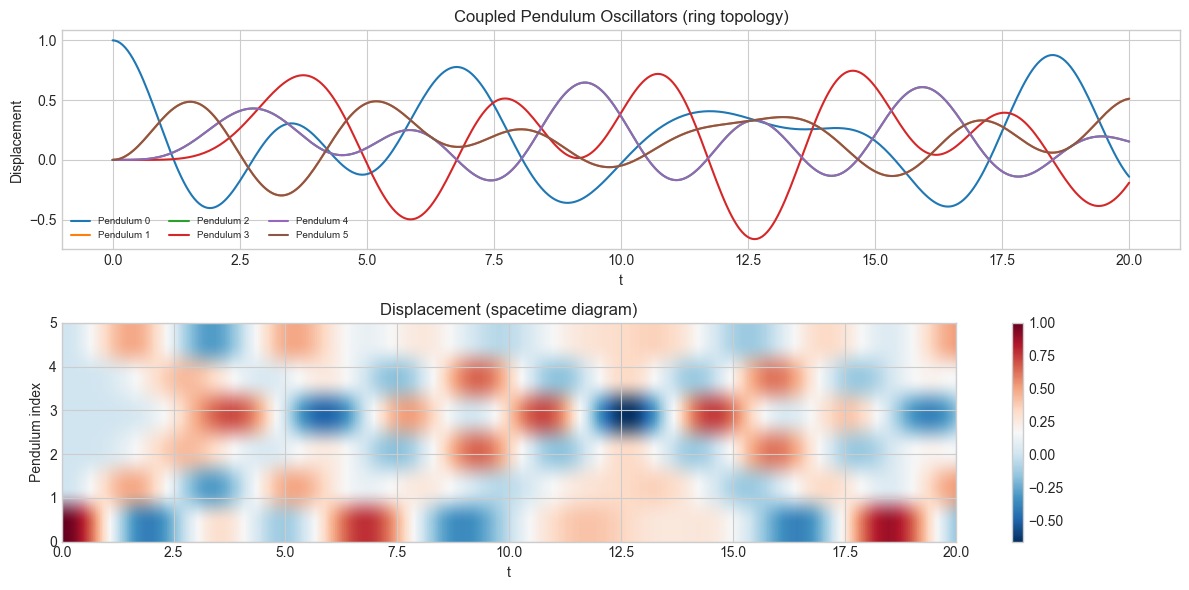

Normal modes visible as standing wave patterns in the spacetime diagram.


In [4]:
# --- Mini Project: Coupled Oscillator Network ---
# n coupled pendulums on a ring: x'' = -L x where L is the graph Laplacian.
# Reformulate as first-order system and simulate.

n_pend = 6   # number of pendulums

# 1D ring Laplacian
L_ring = 2*np.eye(n_pend) - np.roll(np.eye(n_pend), 1, axis=1) - np.roll(np.eye(n_pend), -1, axis=1)

# First-order system: state = [x, v]
# [x']   [ 0   I ] [x]
# [v'] = [-L   0 ] [v]
Z  = np.zeros((n_pend, n_pend))
I  = np.eye(n_pend)
A_osc = np.block([[Z, I], [-L_ring, Z]])

eigs = np.linalg.eigvals(A_osc)
print('Eigenvalues (should be purely imaginary for conservative system):')
print(np.round(eigs, 4))
print('Max real part:', np.real(eigs).max())

# Initial condition: perturb first pendulum
x0 = np.zeros(2 * n_pend)
x0[0] = 1.0   # first pendulum displaced

t_vals = np.linspace(0, 20, 400)
traj = np.array([matrix_exp(A_osc, t).real @ x0 for t in t_vals])

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
for i in range(n_pend):
    axes[0].plot(t_vals, traj[:, i], label=f'Pendulum {i}')
axes[0].set_xlabel('t')
axes[0].set_ylabel('Displacement')
axes[0].set_title('Coupled Pendulum Oscillators (ring topology)')
axes[0].legend(fontsize=7, ncol=3)

im = axes[1].imshow(traj[:, :n_pend].T, aspect='auto', origin='lower',
                   extent=[0, 20, 0, n_pend-1], cmap='RdBu_r')
axes[1].set_xlabel('t')
axes[1].set_ylabel('Pendulum index')
axes[1].set_title('Displacement (spacetime diagram)')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()
print('Normal modes visible as standing wave patterns in the spacetime diagram.')

## 9. Chapter Summary & Connections

- The matrix exponential $e^{At}$ solves $\dot{\mathbf{x}} = A\mathbf{x}$ exactly: $\mathbf{x}(t) = e^{At}\mathbf{x}_0$. Computed via eigendecomposition *(ch172)*: $e^{At} = Ve^{\Lambda t}V^{-1}$.
- Stability of continuous systems: all $\text{Re}(\lambda_i) < 0$. Stability of discrete systems: all $|\lambda_i| < 1$.
- The Lyapunov equation $A^\top P + PA = -Q$ is a special Sylvester equation *(ch198)* whose solution certifies stability.
- Matrix exponentials appear in physics (wave equations), control theory (LQR), signal processing (continuous-time filters), and machine learning (neural ODEs).

**Forward:** Dynamical systems analysis reappears in ch254 (Markov Chains) where the discrete system $\pi_{t+1} = P^\top \pi_t$ and stability is governed by the second eigenvalue of the transition matrix. The continuous analog connects to stochastic differential equations. In Part VII, ch216 (Second Derivatives) connects the Hessian to the stability of gradient descent trajectories — the same eigenvalue analysis applied to an optimization landscape.

**Backward:** This chapter synthesizes ch169 (eigenvectors), ch172 (diagonalization), and ch176 (matrix calculus). The eigendecomposition that makes $e^{At}$ computable is the same tool used throughout Part VI.